<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/2%20K-Nearest%20Neigbours%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

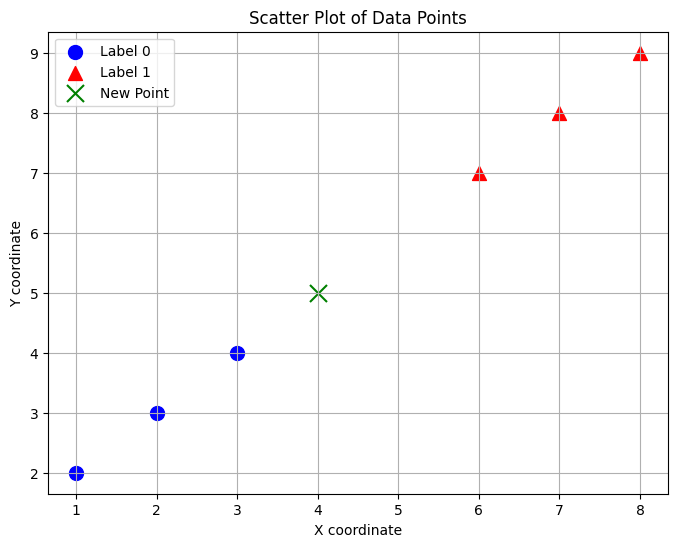

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data points and labels
data_points = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
labels = np.array([0, 0, 0, 1, 1, 1])
new_point = np.array([4, 5])

# Separate data points by their labels
class0 = data_points[labels == 0]
class1 = data_points[labels == 1]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(class0[:, 0], class0[:, 1], color='blue', label='Label 0', s=100, marker='o')  # Class 0
plt.scatter(class1[:, 0], class1[:, 1], color='red', label='Label 1', s=100, marker='^')  # Class 1
plt.scatter(new_point[0], new_point[1], color='green', label='New Point', s=150, marker='x')  # New point

# Adding labels, title and legend
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Scatter Plot of Data Points')
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()


In [3]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_point, data_points, labels, k, distance_metric='euclidean'):
    # Step 1: Calculate distances using pairwise_distances
    distances = pairwise_distances(data_points, new_point, metric=distance_metric).ravel()

    # Step 2 & 3: Sort distances and select k nearest neighbors
    k_nearest_neighbors_indices = np.argsort(distances)[:k]
    k_nearest_labels = labels[k_nearest_neighbors_indices]

    # Step 4: Perform majority vote
    most_common = Counter(k_nearest_labels).most_common(1)

    # Step 5: Determine the predicted class
    predicted_class = most_common[0][0]

    return predicted_class

In [4]:
# Example usage
data_points = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
labels = np.array([0, 0, 0, 1, 1, 1])  # 0 and 1 are class labels
new_point = np.array([[4, 5]])
k = 3
distance_metric = 'euclidean'  # Can be 'euclidean', 'manhattan', 'cosine', etc.

# Classify the new point
predicted_class = kNN_Classify(new_point, data_points, labels, k, distance_metric)
print("Predicted Class:", predicted_class)

Predicted Class: 0


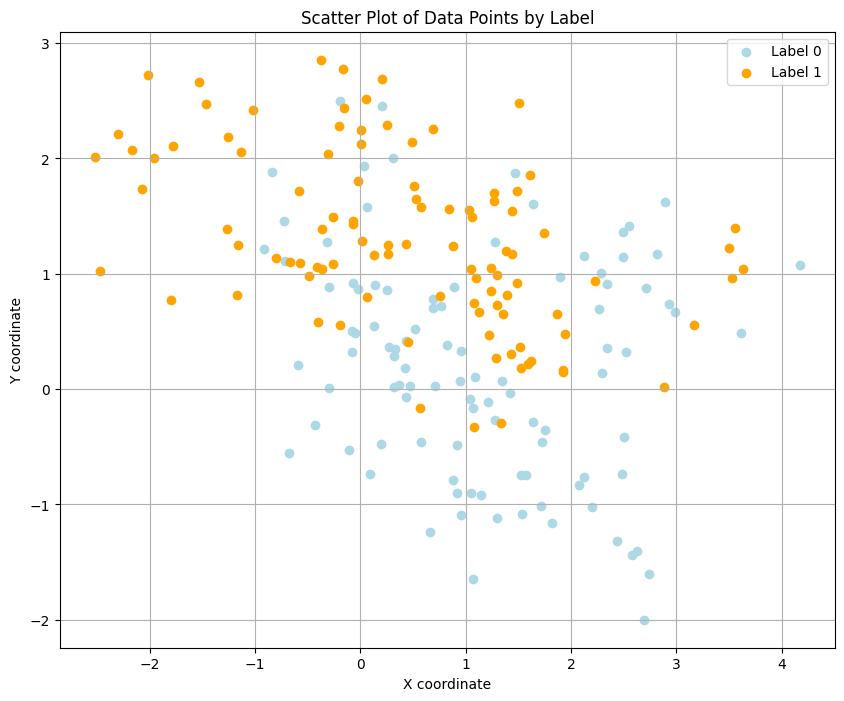

In [6]:
import pandas as pd

# URL for our dataset, mixture-example.csv
URL = "https://drive.google.com/file/d/1l0QDFXeyrelvjXlyhnj4ppP_SSTABIKp/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

data = pd.read_csv(FILE_PATH)

# Filter data by labels
data_0 = data[data['Label'] == 0]
data_1 = data[data['Label'] == 1]

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(data_0['X'], data_0['Y'], color='lightblue', label='Label 0', marker='o')
plt.scatter(data_1['X'], data_1['Y'], color='orange', label='Label 1', marker='o')

# Adding labels and legend
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Scatter Plot of Data Points by Label')
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [42]:
from sklearn.model_selection import train_test_split

# Load the dataset
# data = pd.read_csv('/path/to/mixture-example.csv')  # Adjust path as necessary

# Separate features and labels
X = data[['X', 'Y']].values  # assuming 'X' and 'Y' are your features
y = data['Label'].values  # assuming 'Label' is your label column

# First, split the data into train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Then split the temp data into validation (50% of 40% => 20% of total) and test (remaining 50% of 40% => 20% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the proportion of each set
print("Training Set Size:", len(X_train))
print("Validation Set Size:", len(X_val))
print("Test Set Size:", len(X_test))


Training Set Size: 120
Validation Set Size: 40
Test Set Size: 40


In [43]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_points, data_points, labels, k, distance_metric='euclidean'):
    predictions = []
    for new_point in new_points:
        # Calculate distances
        distances = pairwise_distances(data_points, [new_point], metric=distance_metric).ravel()

        # Get indices of k nearest neighbors
        k_nearest_indices = np.argsort(distances)[:k]
        k_nearest_labels = labels[k_nearest_indices]

        # Perform majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        predicted_class = most_common[0][0]
        predictions.append(predicted_class)

    return predictions

In [44]:
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 3
distance_metric = 'euclidean'

# Call the kNN_Classify function to predict the validation set
predictions = kNN_Classify(X_val, X_train, y_train, k, distance_metric)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)

Accuracy of the k-NN classifier on the validation set: 0.85


In [74]:
from sklearn.base import BaseEstimator, ClassifierMixin
# Define your CustomKNNClassifier following scikit-learn conventions...

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        return self

    def predict(self, X):
        # Your custom predict logic here
        y_pred = []
        for x in X:
            # Calculate distances
            distances = pairwise_distances(self.X_train_, [x], metric=self.distance_metric).ravel()

            # Get indices of k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train_[k_nearest_indices]

            # Perform majority vote
            most_common = Counter(k_nearest_labels).most_common(1)
            predicted_class = most_common[0][0]
            y_pred.append(predicted_class)

        return np.array(y_pred)


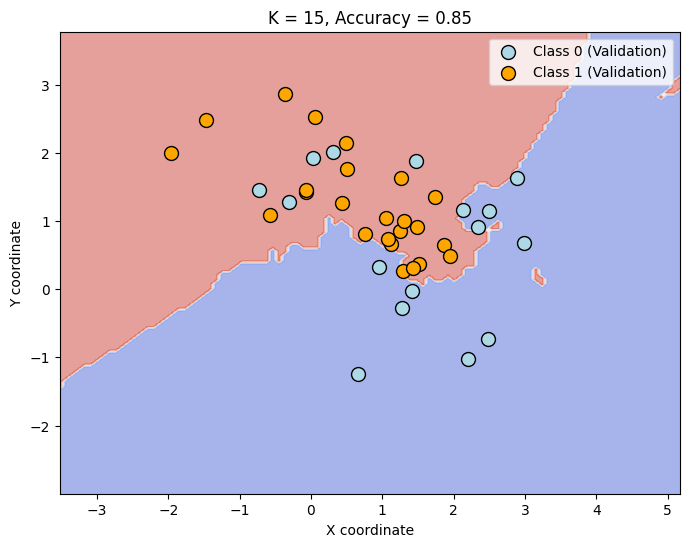

In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

k = 15
distance_metric = "euclidean"

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

In [80]:
neighbours = np.arange(1,31)
accuracy_scores = []
for k in neighbours :
    knn = CustomKNNClassifier(k=k, distance_metric="euclidean")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    accuracy_scores.append(accuracy_score(y_val, y_pred))

accuracy_scores = np.array(accuracy_scores)

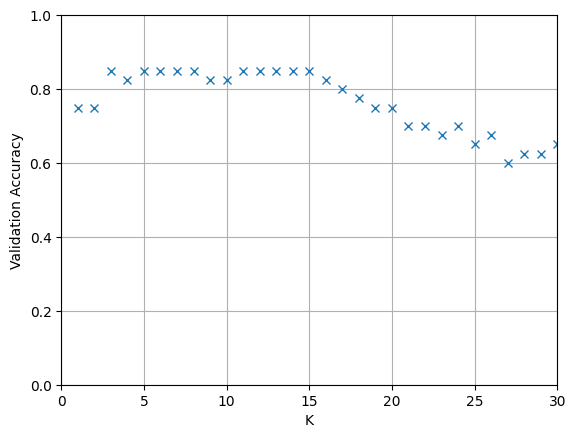

In [84]:
plt.plot(neighbours, accuracy_scores, 'x')
plt.xlabel('K')
plt.ylabel('Validation Accuracy')
plt.axis([0, 30, 0, 1])
plt.grid()
plt.show()

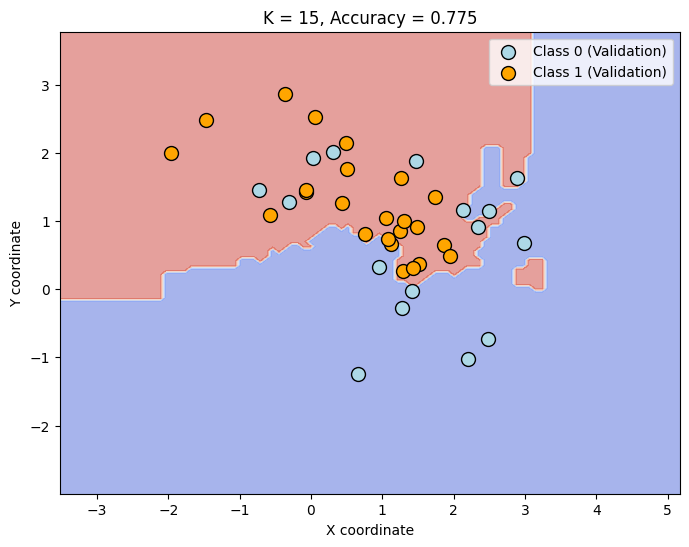

In [91]:
k = 15
distance_metric = "manhattan"

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

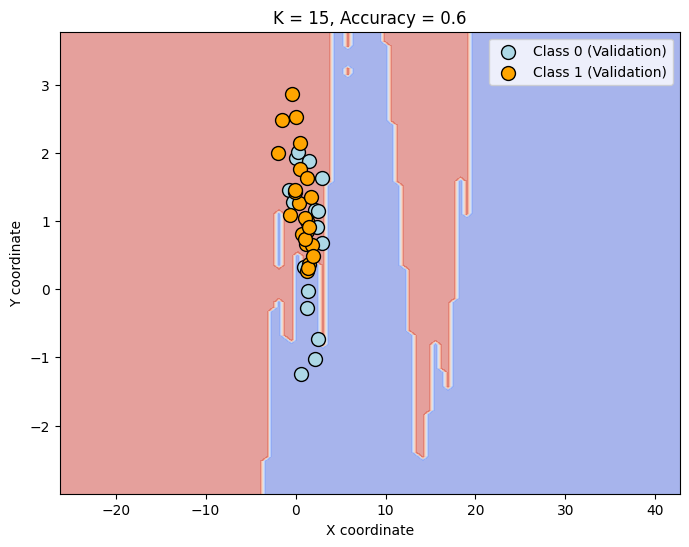

In [93]:
k = 15
distance_metric = "euclidean"
scale = np.array([10, 1])

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(scale*X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    scale*X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(scale*X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()